In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [35]:
df = pd.read_csv('/content/placement_predict_50k.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 31)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.39,6.84,...,1,0,62.3,6.57,40.6,65.7,No,Medium,0,0
1,2,Male,Chennai,Tier2,ECE,AI,Yes,No,5.95,6.74,...,2,0,44.0,5.86,40.3,51.8,No,Medium,0,0
2,3,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.13,8.11,...,2,1,73.8,7.50,73.6,67.9,No,High,1,0
3,4,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.37,9.97,...,6,2,100.0,9.41,98.7,NaN,No,Excellent,1,0
4,5,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,8.25,8.99,...,4,2,90.8,9.24,83.1,100.0,No,Excellent,1,0


In [36]:
# Remove unnecessary column
df = df.drop(columns=['IsAnomaly'], errors='ignore')

# Fill missing values
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)

Missing values: 0
Shape: (50000, 30)


In [37]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (50000, 45)
Target: (50000,)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 45)
Testing data: (10000, 45)


In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Feature scaling completed
Training shape: (40000, 45)
Testing shape: (10000, 45)


In [40]:
C_values = [0.01, 0.1, 1, 10, 100]

print("Regularisation values:", C_values)

Regularisation values: [0.01, 0.1, 1, 10, 100]


In [41]:
from sklearn.linear_model import Ridge

ridge_scores = []

for C in C_values:
    ridge = Ridge(alpha=1/C)
    ridge.fit(X_train_scaled, y_train)

    y_pred = ridge.predict(X_test_scaled)

    # Convert predictions to classes
    y_pred_class = (y_pred >= 0.5).astype(int)

    score = accuracy_score(y_test, y_pred_class)
    ridge_scores.append(score)

print("Ridge Accuracy:")
for C, score in zip(C_values, ridge_scores):
    print("C =", C, "Accuracy =", score)

Ridge Accuracy:
C = 0.01 Accuracy = 0.7943
C = 0.1 Accuracy = 0.7942
C = 1 Accuracy = 0.7942
C = 10 Accuracy = 0.7944
C = 100 Accuracy = 0.7944


In [42]:
from sklearn.linear_model import Lasso

lasso_scores = []

for C in C_values:
    lasso = Lasso(alpha=1/C, max_iter=5000)
    lasso.fit(X_train_scaled, y_train)

    y_pred = lasso.predict(X_test_scaled)
    y_pred_class = (y_pred >= 0.5).astype(int)

    score = accuracy_score(y_test, y_pred_class)
    lasso_scores.append(score)

print("Lasso Accuracy:")
for C, score in zip(C_values, lasso_scores):
    print("C =", C, "Accuracy =", score)

Lasso Accuracy:
C = 0.01 Accuracy = 0.5266
C = 0.1 Accuracy = 0.5266
C = 1 Accuracy = 0.5266
C = 10 Accuracy = 0.7952
C = 100 Accuracy = 0.7934


In [44]:
ridge_scores = []

for C in C_values:
    ridge = LogisticRegression(
        penalty='l2',
        C=C,
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    )

    ridge.fit(X_train_scaled, y_train)

    y_pred = ridge.predict(X_test_scaled)
    score = accuracy_score(y_test, y_pred)

    ridge_scores.append(score)

print("Ridge Accuracy:")
for C, score in zip(C_values, ridge_scores):
    print("C =", C, "Accuracy =", score)

Ridge Accuracy:
C = 0.01 Accuracy = 0.7987
C = 0.1 Accuracy = 0.7988
C = 1 Accuracy = 0.7989
C = 10 Accuracy = 0.7989
C = 100 Accuracy = 0.7989


In [45]:
lasso_scores = []

for C in C_values:
    lasso = LogisticRegression(
        penalty='l1',
        C=C,
        solver='liblinear',
        max_iter=2000,
        random_state=42
    )

    lasso.fit(X_train_scaled, y_train)

    y_pred = lasso.predict(X_test_scaled)
    score = accuracy_score(y_test, y_pred)

    lasso_scores.append(score)

print("Lasso Accuracy:")
for C, score in zip(C_values, lasso_scores):
    print("C =", C, "Accuracy =", score)

Lasso Accuracy:
C = 0.01 Accuracy = 0.7988
C = 0.1 Accuracy = 0.7994
C = 1 Accuracy = 0.7989
C = 10 Accuracy = 0.7991
C = 100 Accuracy = 0.7991


        C  Ridge_Accuracy  Lasso_Accuracy
0    0.01          0.7987          0.7988
1    0.10          0.7988          0.7994
2    1.00          0.7989          0.7989
3   10.00          0.7989          0.7991
4  100.00          0.7989          0.7991


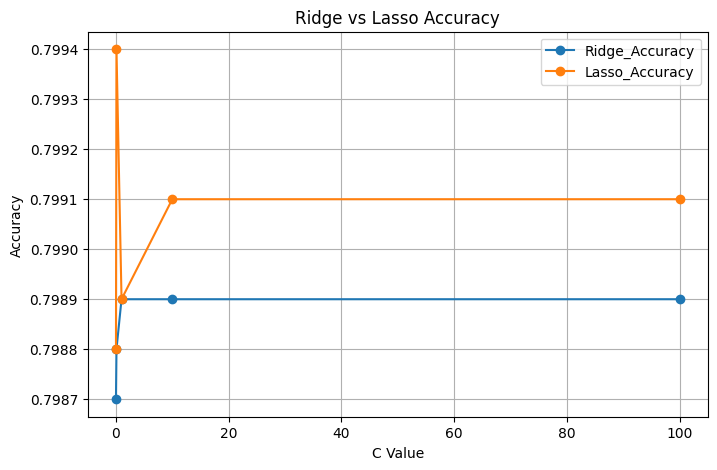

In [46]:
results = pd.DataFrame({
    'C': C_values,
    'Ridge_Accuracy': ridge_scores,
    'Lasso_Accuracy': lasso_scores
})

print(results)

results.plot(
    x='C',
    y=['Ridge_Accuracy', 'Lasso_Accuracy'],
    marker='o',
    figsize=(8, 5)
)

plt.title("Ridge vs Lasso Accuracy")
plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [47]:
ridge_nonzero = np.sum(ridge.coef_ != 0)
lasso_nonzero = np.sum(lasso.coef_ != 0)

print("Ridge non-zero coefficients:", ridge_nonzero)
print("Lasso non-zero coefficients:", lasso_nonzero)

Ridge non-zero coefficients: 45
Lasso non-zero coefficients: 45
